# Credit Card Customer Segmentation

## Project Overview
The objective of this project is to perform customer segmentation on a credit card dataset containing usage behavior of approximately 9,000 active credit card holders over six months. By applying clustering techniques, we aim to identify distinct groups within the customer base that can help inform targeted marketing strategies. The dataset includes features such as purchase amounts, cash advances, credit limit, and payment amounts, which are critical for understanding customer behavior.

## Dataset
- **Source:**(Credit Card Dataset for Clustering)
- **Size:** 8950 records
- **Key Features:**
  - `PURCHASES`: Amount of purchases made
  - `CREDIT_LIMIT`: Customer's credit limit
  - `CASH_ADVANCE`, `PAYMENTS`, `BALANCE_FREQUENCY`

## Methodology
1. **Data Preprocessing:**
   - Handled missing values (`CREDIT_LIMIT` filled with median)
   - Load the dataset using Pandas and perform an initial exploration to understand the structure and characteristics of the data.
     Check for missing values, duplicates, and data types to ensure data integrity.

2   **Hierarchical Clustering:
    - Perform hierarchical clustering using the linkage method from the SciPy library.
    - Generate a dendrogram to visualize the clustering process, which helps in determining the number of clusters.


3. **Clustering Techniques:**
   - **Hierarchical Clustering:**
     - Used Ward’s method to generate a dendrogram
   - **K-Means Clustering:**
     - Determined optimal `k` using the Elbow Method
     - Applied K-Means and assigned clusters

4. **Visualization:**
   - Scatter plot of `PURCHASES` vs. `CREDIT_LIMIT` with cluster labels

Silhouette Scores:
    - The silhouette scores indicated optimal cluster numbers, helping validate the chosen K in K-means clustering.
      Higher silhouette scores suggested well-defined and separated clusters.

## Results & Interpretation
- Customers were grouped into three clusters:
  1. **Low Purchases, Low Credit Limit**
  2. **Moderate Purchases, Moderate Credit Limit**
  3. **High Purchases, High Credit Limit**

## Conclusion
The clustering analysis successfully identified distinct customer segments within the credit card dataset. These segments offer valuable insights for targeted marketing strategies, allowing businesses to tailor their approaches based on customer behavior patterns. Understanding these groups can lead to improved customer satisfaction, increased engagement, and more effective allocation of marketing resources.

## Technologies Used
- Python (Pandas, NumPy, Scikit-Learn, Matplotlib, Seaborn, SciPy)

  ## StudentName: Olalekan Elebute (GMC/DS)

In [99]:
##importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [101]:
## loading dataset using pandas
Cc = pd.read_csv("Credit_card_dataset.csv")
Cc.head()

,CUST_ID,BALANCE_FREQUENCY,PURCHASES,PAYMENTS,CREDIT_LIMIT,CASH_ADVANCE
0,C10001,0.818182,95.40,201.802084,1000.0,0.000000
1,C10002,0.909091,0.00,4103.032597,7000.0,6442.945483
2,C10003,1.000000,773.17,622.066742,7500.0,0.000000
3,C10004,0.636364,1499.00,0.000000,7500.0,205.788017
4,C10005,1.000000,16.00,678.334763,1200.0,0.000000


In [102]:
Cc.describe()

,BALANCE_FREQUENCY,PURCHASES,PAYMENTS,CREDIT_LIMIT,CASH_ADVANCE
count,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000
mean,0.877271,1003.204834,1733.143852,4494.449450,978.871112
std,0.236904,2136.634782,2895.063757,3638.815725,2097.163877
min,0.000000,0.000000,0.000000,50.000000,0.000000
25%,0.888889,39.635000,383.276166,1600.000000,0.000000
50%,1.000000,361.280000,856.901546,3000.000000,0.000000
75%,1.000000,1110.130000,1901.134317,6500.000000,1113.821139
max,1.000000,49039.570000,50721.483360,30000.000000,47137.211760


In [103]:
Cc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CUST_ID            8950 non-null   object 
 1   BALANCE_FREQUENCY  8950 non-null   float64
 2   PURCHASES          8950 non-null   float64
 3   PAYMENTS           8950 non-null   float64
 4   CREDIT_LIMIT       8949 non-null   float64
 5   CASH_ADVANCE       8950 non-null   float64
dtypes: float64(5), object(1)
memory usage: 419.7+ KB


In [107]:
Cc.isnull().sum()

CUST_ID              0
BALANCE_FREQUENCY    0
PURCHASES            0
PAYMENTS             0
CREDIT_LIMIT         1
CASH_ADVANCE         0
dtype: int64

In [108]:
Cc.dtypes

CUST_ID               object
BALANCE_FREQUENCY    float64
PURCHASES            float64
PAYMENTS             float64
CREDIT_LIMIT         float64
CASH_ADVANCE         float64
dtype: object

In [109]:
Cc["CREDIT_LIMIT"].fillna(Cc["CREDIT_LIMIT"].median(), inplace=True)

In [110]:
Cc.isnull().sum()

CUST_ID              0
BALANCE_FREQUENCY    0
PURCHASES            0
PAYMENTS             0
CREDIT_LIMIT         0
CASH_ADVANCE         0
dtype: int64

In [115]:
## normalizing data
Cc_1 = Cc[["PURCHASES", "CREDIT_LIMIT"]]
normalized_data = normalize(Cc_1)
normalized_data

array([[0.09496882, 0.99548025],
       [0.        , 1.        ],
       [0.10254587, 0.99472828],
       ...,
       [0.14291767, 0.98973458],
       [0.        , 1.        ],
       [0.67346195, 0.73922189]])

In [117]:
normalized_Cc = pd.DataFrame(normalized_data, columns= Cc_1.columns)
normalized_Cc.head()

,PURCHASES,CREDIT_LIMIT
0,0.094969,0.995480
1,0.000000,1.000000
2,0.102546,0.994728
3,0.195990,0.980606
4,0.013332,0.999911


In [119]:
# Scaling the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled = scaler.fit_transform(normalized_Cc[['PURCHASES', 'CREDIT_LIMIT']])
data_scaled

array([[-0.46565091,  0.45747213],
       [-0.8769007 ,  0.49870133],
       [-0.43283946,  0.45061264],
       ...,
       [-0.25801477,  0.40506012],
       [-0.8769007 ,  0.49870133],
       [ 2.03943643, -1.8801179 ]])

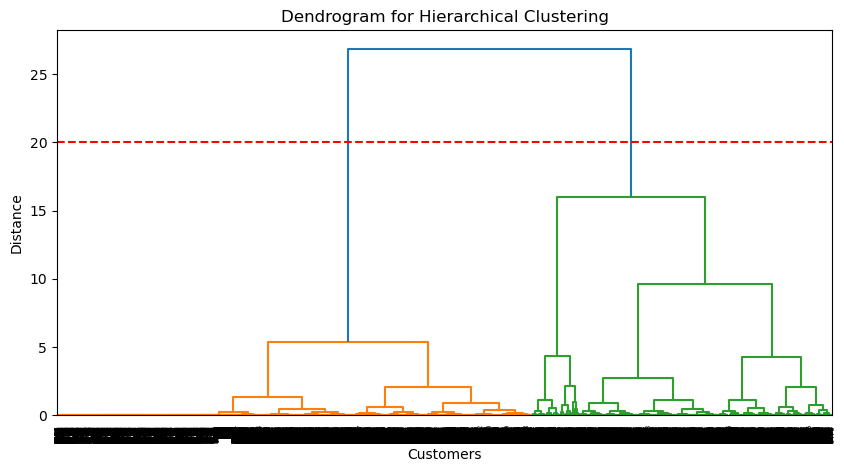

In [121]:
# Perform hierarchical clustering
linked = linkage(normalized_Cc, method="ward")

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.axhline(y=20, color = "r", linestyle ="--")
plt.show()

In [125]:
# Fit the Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering
AC = AgglomerativeClustering(n_clusters= 2, metric="euclidean", linkage="ward")

In [127]:
# Fit and predict to have the cluster labels
y_pred = AC.fit_predict(normalized_Cc)
y_pred

array([1, 1, 1, ..., 1, 1, 0], dtype=int64)

In [129]:
# Fetch the cluster labels
df["cluster labels"] = y_pred

In [ ]:
# Removing outliers (example using IQR)
Q1 = normalized_Cc[['PURCHASES', 'CREDIT_LIMIT']].quantile(0.25)
Q3 = normalized_Cc[['PURCHASES', 'CREDIT_LIMIT']].quantile(0.75)
IQR = Q3 - Q1
normalized_Cc = normalized_Cc[~((normalized_Cc[['PURCHASES', 'CREDIT_LIMIT']] < 
(Q1 - 1.5 * IQR)) | (normalized_Cc[['PURCHASES', 'CREDIT_LIMIT']] > (Q3 + 1.5 * IQR))).any(axis=1)]

<Axes: xlabel='cluster labels', ylabel='CREDIT_LIMIT'>

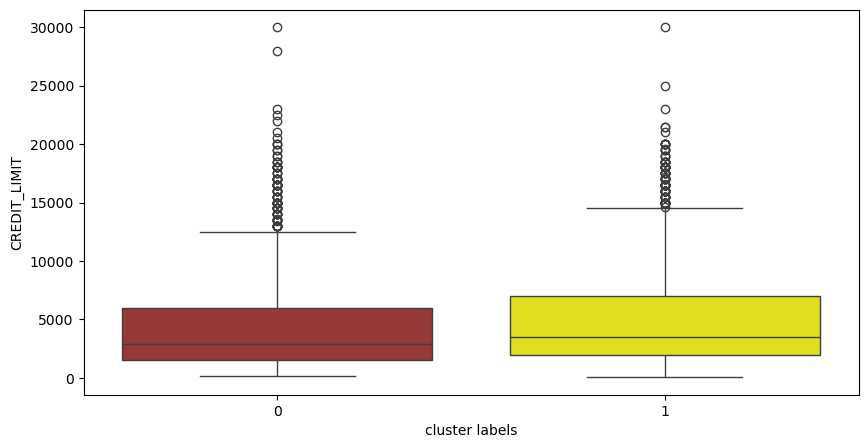

In [131]:
plt.figure(figsize=(10,5))
sns.boxplot(x="cluster labels", y="CREDIT_LIMIT", data=df, palette= ["brown", "yellow", "purple"])

<Axes: xlabel='cluster labels', ylabel='PAYMENTS'>

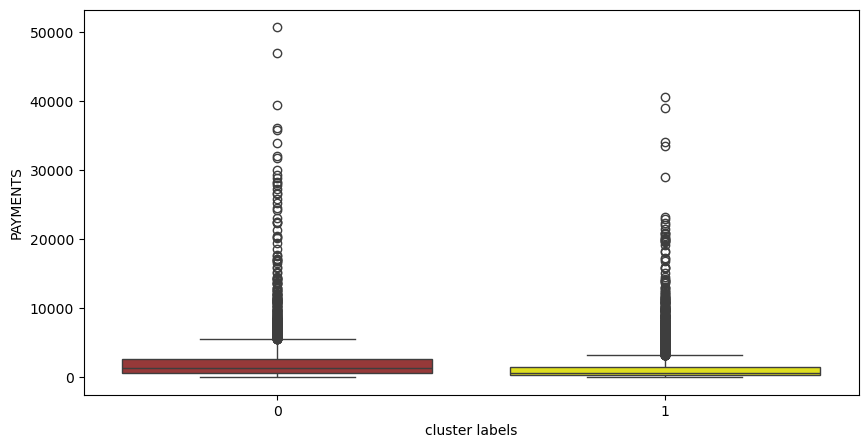

In [133]:
plt.figure(figsize=(10,5))
sns.boxplot(x="cluster labels", y="PAYMENTS", data=df, palette= ["brown", "yellow", "purple"])

<Axes: xlabel='cluster labels', ylabel='PURCHASES'>

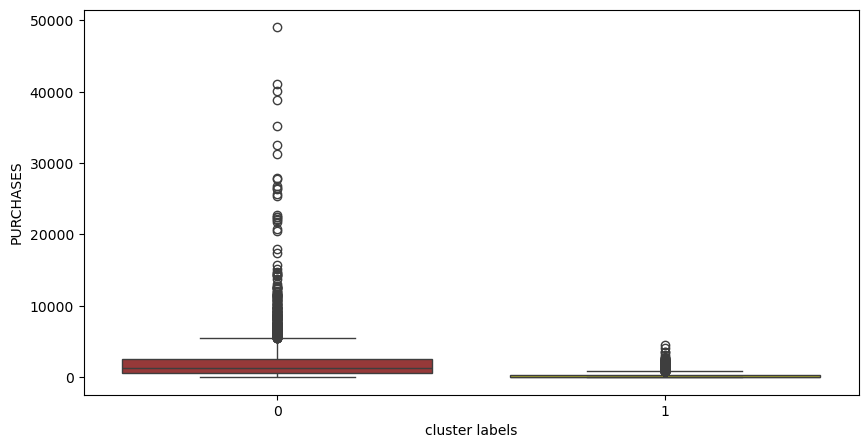

In [135]:
plt.figure(figsize=(10,5))
sns.boxplot(x="cluster labels", y="PURCHASES", data=df, palette= ["brown", "yellow", "purple"])

In [141]:
df.rename(columns = {"cluster labels":"cluster"}, inplace = True)

In [143]:
CC1 = df[df.cluster == 0]
CC2 = df[df.cluster == 1]

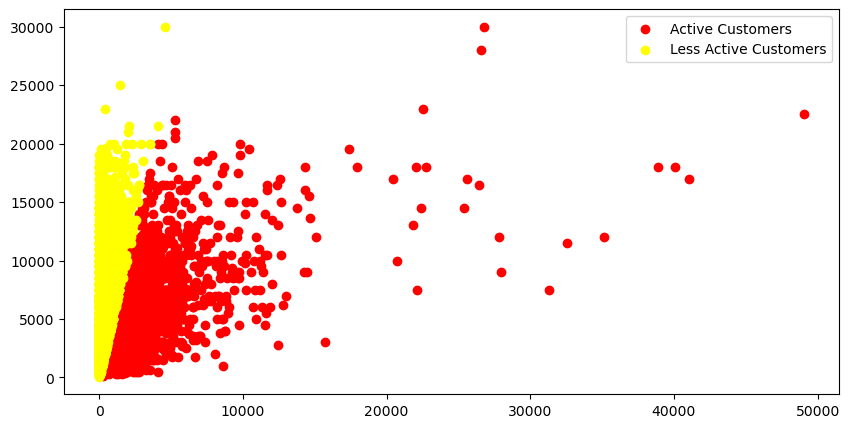

In [147]:
plt.figure(figsize=(10,5))
plt.scatter(CC1.PURCHASES, CC1.CREDIT_LIMIT, c='red', label ='Active Customers')
plt.scatter(CC2.PURCHASES, CC2.CREDIT_LIMIT, c='yellow', label ='Less Active Customers')
plt.legend()
plt.show()

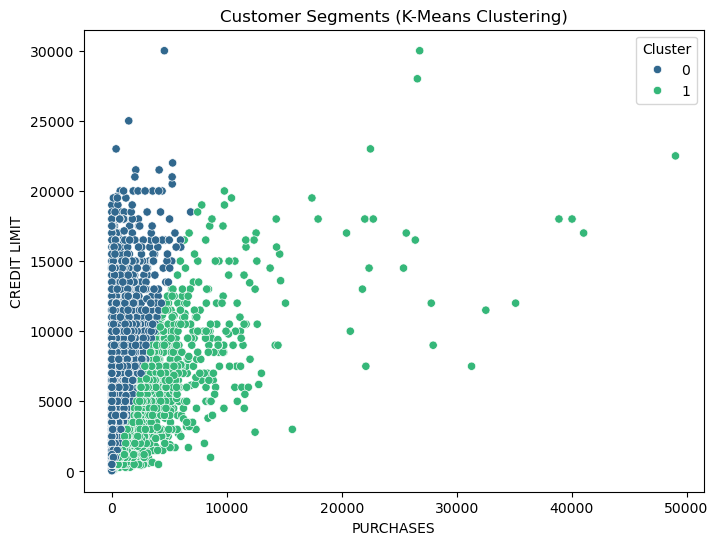

In [167]:
# Apply K-Means with the chosen number of clusters (e.g., k=3)
kmeans = KMeans(n_clusters=2, random_state=42)
df["Cluster"] = kmeans.fit_predict(normalized_Cc)

# Visualize clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df["PURCHASES"], y=df["CREDIT_LIMIT"], hue=df["Cluster"], palette="viridis")
plt.title("Customer Segments (K-Means Clustering)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT LIMIT")
plt.legend(title="Cluster")
plt.show()

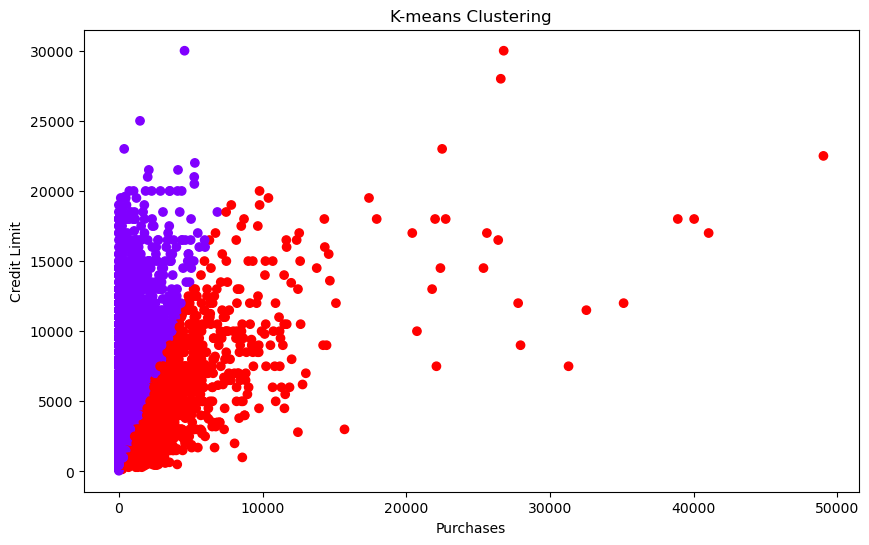

In [169]:
# Plotting the clusters
plt.figure(figsize=(10, 6))
plt.scatter(df['PURCHASES'], df['CREDIT_LIMIT'], c=df['Cluster'], cmap='rainbow')
plt.title('K-means Clustering')
plt.xlabel('Purchases')
plt.ylabel('Credit Limit')
plt.show()

In [175]:
# Using the silhouette score to find the best K
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 11)

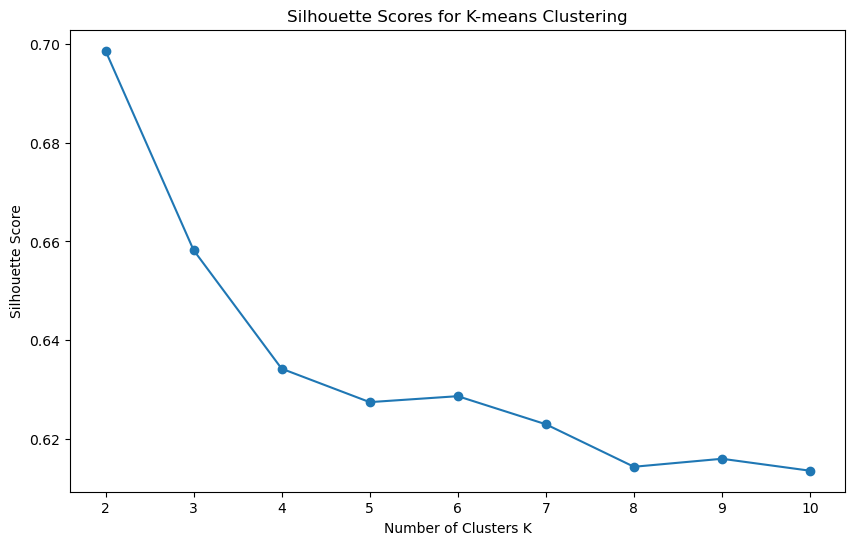

In [177]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(normalized_Cc)
    score = silhouette_score(normalized_Cc, kmeans.labels_)
    silhouette_scores.append(score)

# Plotting the silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='o')
plt.title('Silhouette Scores for K-means Clustering')
plt.xlabel('Number of Clusters K')
plt.ylabel('Silhouette Score')
plt.show()

In [183]:
# Evaluate the silhouette scores to determine the optimal number of clusters.
#Analyze the characteristics of each cluster by examining the mean or median values of `PURCHASES` and `CREDIT_LIMIT` for each cluster.
#Consider how these segments might inform marketing strategies, e.g., targeting high spenders or customers with low credit utilization.

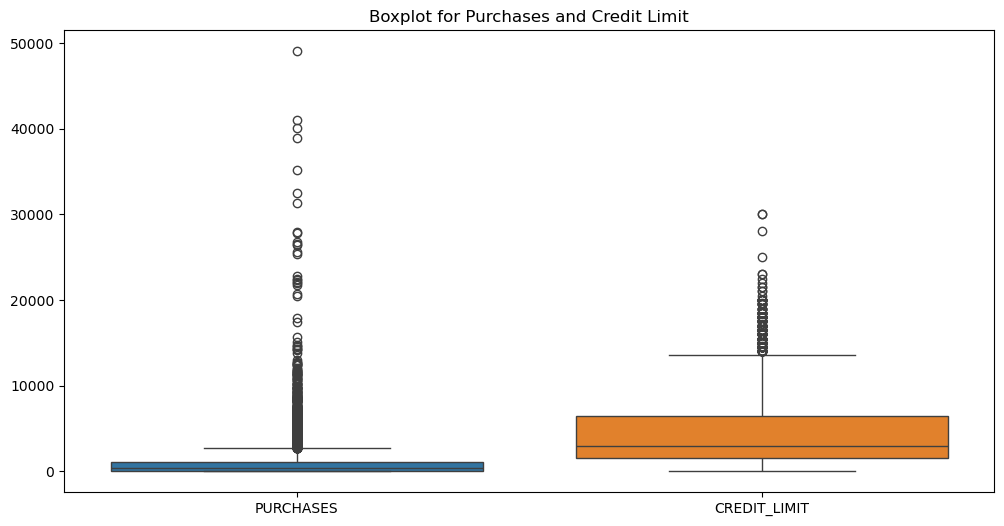

In [189]:
# Visualizing outliers using boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['PURCHASES', 'CREDIT_LIMIT']])
plt.title('Boxplot for Purchases and Credit Limit')
plt.show()